# Weather Impact on Agricultural Commodities: Code Outline and Initial Results

**MScFE 690 Capstone, Commodities track, Topic 3 (Weather Impact on Agricultural Commodities)**
Minh Tien Phung · Minh Chau Pham

Code outline and **preliminary results** for the three parts of our problem statement:

1. **Price relationships:** corn vs wheat, and soybean oil vs rapeseed oil, in the **US** and the **EU**.
2. **Weather and production:** growing-season temperature and precipitation against crop yields.
3. **Spreads and speed of mean reversion**, compared across the two regions.

| § | Section | Status |
|---|---|---|
| 1 | Setup | done |
| 2 | Data collection | done (first version) |
| 3 | Data cleaning and quality checks | done (first pass) |
| 4 | Exploratory data analysis | done (first pass) |
| 5 | Seasonality (STL, FFT, seasonal dummies) and ARIMA | first pass |
| 6 | Price relationships: stationarity, correlation, cointegration | first pass |
| 7 | Weather and yield regressions | first pass |
| 8 | Spreads and speed of mean reversion | first pass |
| 9 | Initial findings | preliminary |

### Data sources

| Data | Source | Frequency | Coverage |
|---|---|---|---|
| US futures: corn (`ZC`), wheat (`ZW`, soft red winter), soybean oil (`ZL`), CBOT continuous front month; `EUR/USD` | Yahoo Finance via `yfinance` | daily | 2014 onward |
| EU cash prices: breadmaking common wheat and feed maize, EU average | European Commission, Agri-food Data Portal API | weekly | Nov 2015 onward |
| Vegetable oils: soybean oil (Dutch, EXW/FOB), rapeseed oil (FOB Rotterdam); US Gulf maize and wheat for reference | World Bank Commodity Price Data (Pink Sheet) | monthly | 1960 onward |
| Weather: `2 m` temperature (mean, maximum), precipitation, at points in the main growing areas | NASA POWER API (agroclimatology) | monthly | 1981 onward |
| Production, area harvested, yield for the US and the EU | USDA FAS Production, Supply and Distribution (PSD) | annual (marketing year) | US 1960 onward, EU 1999 onward |

**Pairs studied.** US corn–wheat uses CBOT futures, EU corn–wheat uses EU-average cash prices, and the EU oil pair uses Dutch soybean oil vs Rotterdam rapeseed oil. No free US canola oil price is available yet, so the US oil pair is proxied by **CBOT soybean oil vs Rotterdam rapeseed oil**.

## 1. Setup

In [1]:
import sys

if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "yfinance", "openpyxl"], check=True)

In [ ]:
import calendar
import io
import time
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
import yfinance as yf
from IPython.display import display
from scipy import signal, stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, coint, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_order

warnings.filterwarnings("ignore")   
pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# configuration
START = "2014-01-01"                              # price sample start (about 10+ years of data)
TODAY = pd.Timestamp.today().normalize()
LAST_FULL_MONTH = TODAY - pd.offsets.MonthEnd(1)  # drop the current, incomplete month from monthly data
WEATHER_YEARS = (1981, TODAY.year - 1)            # NASA POWER monthly data: complete years only
LAST_HARVEST = TODAY.year - 1                     # drop current-year USDA projections
REFRESH_DATA = True                              # True: download again; False: reuse cached CSVs in data/raw

DATA_DIR = Path("data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)
HTTP = {"User-Agent": "Mozilla/5.0 (MScFE capstone research)"}
print(f"Run date: {TODAY:%Y-%m-%d} | pandas {pd.__version__} | statsmodels {sm.__version__}")

Run date: 2026-09-28 | pandas 2.3.0 | statsmodels 0.14.4


In [ ]:
COLORS = {"corn": "#2a78d6", "wheat": "#eb6834", "soyoil": "#1baf7a", "rapeoil": "#eda100"}
REGION = {"US": "#4a3aa7", "EU": "#e34948"}
INK, INK2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "axes.titlecolor": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 1.5, "legend.frameon": False, "legend.fontsize": 8.5, "font.size": 9,
})

LABELS = {"corn_us": "US corn", "wheat_us": "US wheat", "soyoil_us": "US soybean oil",
          "corn_eu": "EU maize", "wheat_eu": "EU wheat", "soyoil_eu": "EU soybean oil", "rapeoil_eu": "EU rapeseed oil"}
MONTHLY_SERIES = list(LABELS)
GRAINS = ["corn_us", "wheat_us", "corn_eu", "wheat_eu"]


def commodity(col):
    """'corn_us' -> 'corn' (key into COLORS)."""
    return col.split("_")[0]


def fig_title(fig, text):
    fig.suptitle(text, x=0.01, ha="left", fontsize=11, fontweight="bold", color=INK)

In [4]:
def cached(name, fetch, date_index=True):
    """Return data/raw/<name>.csv if it exists (and REFRESH_DATA is False); otherwise run fetch() and cache it."""
    path = DATA_DIR / f"{name}.csv"
    if path.exists() and not REFRESH_DATA:
        df = pd.read_csv(path, index_col=0)
        if date_index:
            df.index = pd.to_datetime(df.index)
        return df
    df = fetch()
    df.to_csv(path)
    return df


def http_get(url, timeout=120, **kwargs):
    r = requests.get(url, headers=HTTP, timeout=timeout, **kwargs)
    r.raise_for_status()
    return r

## 2. Data collection

### 2.1 US futures prices (CBOT, daily)
Continuous front-month futures from Yahoo Finance, converted to `USD/t` so both pairs share one unit. `EUR/USD` is downloaded for cross-region comparisons.

In [5]:
US_TICKERS = {"corn_us": "ZC=F", "wheat_us": "ZW=F", "soyoil_us": "ZL=F"}   # CBOT continuous front month
FX_TICKER = {"eurusd": "EURUSD=X"}                                          # USD per EUR
TO_USD_T = pd.Series({"corn_us": 0.393683,     # US cents per bushel (56 lb) -> USD per tonne
                      "wheat_us": 0.367437,    # US cents per bushel (60 lb) -> USD per tonne
                      "soyoil_us": 22.0462})   # US cents per lb -> USD per tonne


def fetch_yahoo():
    tickers = {**US_TICKERS, **FX_TICKER}
    close = yf.download(list(tickers.values()), start=START, auto_adjust=False, progress=False)["Close"]
    close = close.rename(columns={v: k for k, v in tickers.items()})[list(tickers)]
    if close.index.tz is not None:
        close.index = close.index.tz_localize(None)
    close.index.name = "date"
    return close


yahoo = cached("yahoo_daily", fetch_yahoo)
yahoo.columns.name = None
us_daily = (yahoo[list(US_TICKERS)] * TO_USD_T).dropna(how="all")   # USD/t on CBOT trading days
eurusd = yahoo["eurusd"].dropna()
print(f"US futures: {us_daily.index.min():%Y-%m-%d} to {us_daily.index.max():%Y-%m-%d} ({len(us_daily):,} trading days)")
us_daily.tail(3)

US futures: 2014-01-02 to 2026-09-28 (3,202 trading days)


,corn_us,wheat_us,soyoil_us
date,,,
2026-09-24,207.668,259.778,"1,475.552"
2026-09-25,207.963,258.400,"1,482.827"
2026-09-28,205.601,252.613,"1,490.984"


### 2.2 EU cereal prices (European Commission, weekly)
EU-average prices (`EUR/t`) for breadmaking common wheat and feed maize. The API returns one year per request.

In [6]:
EC_API = "https://api.tech.ec.europa.eu/agrifood/api"
EU_CEREALS = {"Breadmaking common wheat": "wheat_eu", "Feed maize": "corn_eu"}


def parse_eur(value):
    """'€194,58' -> 194.58 (the API uses a decimal comma)."""
    s = str(value).replace("€", "").strip()
    return float(s.replace(".", "").replace(",", ".")) if "," in s else float(s)


def fetch_eu_cereals():
    records = []
    for year in range(2015, TODAY.year + 1):
        params = {"memberStateCodes": "EU", "productCodes": "BLTPAN,MAI",
                  "beginDate": f"01/01/{year}", "endDate": f"31/12/{year}"}
        r = requests.get(f"{EC_API}/cereal/prices", params=params, headers=HTTP, timeout=120)
        if r.status_code == 404:          # the API answers 404 when a request has no data
            continue
        r.raise_for_status()
        records += r.json()
    df = pd.DataFrame(records)
    # keep one consistent definition: the EU average ("National Average" stage) of the two products
    df = df[df["productName"].isin(EU_CEREALS) & df["stageName"].str.startswith("National Average")].copy()
    df["series"] = df["productName"].map(EU_CEREALS)
    df["price"] = df["price"].map(parse_eur)
    # weeks run Monday to Sunday; stamp each week on its Friday to line up with US weekly closes
    df["date"] = pd.to_datetime(df["beginDate"], dayfirst=True) + pd.Timedelta(days=4)
    return df.pivot_table(index="date", columns="series", values="price", aggfunc="mean")[["corn_eu", "wheat_eu"]]


eu_weekly = cached("eu_cereals_weekly", fetch_eu_cereals)
print(f"EU cereals: {eu_weekly.index.min():%Y-%m-%d} to {eu_weekly.index.max():%Y-%m-%d} ({len(eu_weekly)} weeks)")
eu_weekly.tail(3)

EU cereals: 2015-11-20 to 2026-07-31 (550 weeks)


,corn_eu,wheat_eu
date,,
2026-07-17,222.940,201.130
2026-07-24,231.840,203.900
2026-07-31,225.660,206.830


### 2.3 Vegetable oil prices (World Bank Pink Sheet, monthly)
Monthly averages in `USD/t`. Both oil quotes are European (Dutch mills, FOB Rotterdam), which gives the EU oil pair. US Gulf maize and soft red winter wheat are kept as references.

In [7]:
WB_URLS = [   # the World Bank re-publishes this file under a new path each year: try the newest first
    "https://thedocs.worldbank.org/en/doc/74e8be41ceb20fa0da750cda2f6b9e4e-0050012026/related/CMO-Historical-Data-Monthly.xlsx",
    "https://thedocs.worldbank.org/en/doc/5d903e848db1d1b83e0ec8f744e55570-0350012021/related/CMO-Historical-Data-Monthly.xlsx",
]
WB_SERIES = {"Soybean oil": "soyoil_eu",      # Dutch soybean oil, EXW Dutch mills (earlier FOB NW Europe)
             "Rapeseed oil": "rapeoil_eu",    # Dutch rapeseed oil, FOB Rotterdam
             "Maize": "corn_gulf",            # US No. 2 yellow, FOB US Gulf
             "Wheat, US SRW": "wheat_gulf"}   # US No. 2 soft red winter, US Gulf


def fetch_world_bank():
    for url in WB_URLS:
        try:
            content = http_get(url).content
            break
        except requests.RequestException:
            continue
    else:
        raise RuntimeError("World Bank Pink Sheet not reachable: update WB_URLS from the Pink Sheet web page")
    raw = pd.read_excel(io.BytesIO(content), sheet_name="Monthly Prices", header=None)
    header = raw.index[raw.apply(lambda row: row.astype(str).str.fullmatch("Maize").any(), axis=1)][0]
    data = raw.iloc[header + 2:].set_axis(["period"] + raw.iloc[header, 1:].tolist(), axis=1)
    data = data[data["period"].astype(str).str.fullmatch(r"\d{4}M\d{2}")]
    data.index = pd.PeriodIndex(data["period"].str.replace("M", "-"), freq="M").to_timestamp(how="end").normalize()
    out = data[list(WB_SERIES)].apply(pd.to_numeric, errors="coerce").astype(float).rename(columns=WB_SERIES)
    out.index.name = "date"
    return out


wb_monthly = cached("world_bank_monthly", fetch_world_bank).astype(float)
print(f"World Bank: {wb_monthly.index.min():%Y-%m} to {wb_monthly.index.max():%Y-%m}")
wb_monthly.tail(3)

World Bank: 1960-01 to 2026-08


,soyoil_eu,rapeoil_eu,corn_gulf,wheat_gulf
date,,,,
2026-06-30,"1,740.000","1,522.000",197.100,237.500
2026-07-31,"1,658.000","1,488.000",213.400,258.100
2026-08-31,"1,638.000","1,474.000",224.000,263.200


### 2.4 Weather (NASA POWER, monthly)
Monthly mean temperature (`tmean`), maximum temperature (`tmax`) and total precipitation (`prcp`) at representative points in each crop's main producing areas. These points are a first approximation; production-weighted regional averages are planned.

In [8]:
POWER_API = "https://power.larc.nasa.gov/api/temporal/monthly/point"
SITES = {                              # (latitude, longitude)
    "US_Iowa":         (42.0, -93.5),  # corn, soybeans
    "US_Illinois":     (40.0, -89.0),  # corn, soybeans, soft red winter wheat
    "US_Kansas":       (38.5, -98.5),  # hard red winter wheat
    "EU_FR_Beauce":    (48.3,   1.6),  # wheat
    "EU_FR_Champagne": (48.9,   4.4),  # rapeseed, wheat
    "EU_DE_North":     (53.6,  11.5),  # rapeseed, wheat
    "EU_PL_Centre":    (52.4,  17.5),  # rapeseed, wheat
    "EU_FR_SouthWest": (43.7,   0.5),  # maize
    "EU_RO_South":     (44.4,  26.0),  # maize, wheat
}


def fetch_power():
    frames = []
    for site, (lat, lon) in SITES.items():
        params = {"parameters": "T2M,T2M_MAX,PRECTOTCORR_SUM", "community": "AG", "latitude": lat, "longitude": lon,
                  "start": WEATHER_YEARS[0], "end": WEATHER_YEARS[1], "format": "JSON"}
        values = http_get(POWER_API, params=params).json()["properties"]["parameter"]
        df = pd.DataFrame(values)
        df = df[~df.index.str.endswith("13")]                 # drop the annual summary ("month 13")
        df.index = pd.to_datetime(df.index, format="%Y%m") + pd.offsets.MonthEnd(0)
        df = df.replace(-999, np.nan).rename(columns={"T2M": "tmean", "T2M_MAX": "tmax", "PRECTOTCORR_SUM": "prcp"})
        frames.append(df.assign(site=site))
        time.sleep(0.5)                                       # be polite to the API
    out = pd.concat(frames)
    out.index.name = "date"
    return out


weather = cached("nasa_power_monthly", fetch_power)
print(f"Weather: {weather['site'].nunique()} sites, {weather.index.min():%Y-%m} to {weather.index.max():%Y-%m}")
weather.groupby("site")[["tmean", "tmax", "prcp"]].mean().round(1)

Weather: 9 sites, 1981-01 to 2025-12


,tmean,tmax,prcp
site,,,
EU_DE_North,8.900,19.400,58.500
EU_FR_Beauce,10.700,22.000,54.100
EU_FR_Champagne,10.200,21.600,62.600
EU_FR_SouthWest,13.600,27.000,62.700
EU_PL_Centre,8.600,20.300,49.600
EU_RO_South,12.000,25.400,45.100
US_Illinois,11.100,25.100,82.600
US_Iowa,9.400,24.100,72.100
US_Kansas,13.000,29.300,59.500


### 2.5 Production and yield (USDA PSD, annual)
Yield (`t/ha`), production and area for the US and the EU. Marketing years are labelled by harvest year, so a crop harvested in 2024 matches 2024 growing-season weather.

In [9]:
PSD_FILES = ["psd_grains_pulses_csv.zip", "psd_oilseeds_csv.zip"]
PSD_CROPS = {"Corn": "corn", "Wheat": "wheat", "Oilseed, Soybean": "soybeans", "Oilseed, Rapeseed": "rapeseed",
             "Oil, Soybean": "soyoil", "Oil, Rapeseed": "rapeoil"}


def fetch_psd():
    frames = []
    for name in PSD_FILES:
        z = zipfile.ZipFile(io.BytesIO(http_get(f"https://apps.fas.usda.gov/psdonline/downloads/{name}", timeout=300).content))
        frames.append(pd.read_csv(z.open(z.namelist()[0])))
    psd = pd.concat(frames)
    keep = (psd["Country_Name"].isin(["United States", "European Union"])
            & psd["Commodity_Description"].isin(PSD_CROPS)
            & psd["Attribute_Description"].isin(["Production", "Area Harvested", "Yield"]))
    psd = psd[keep].assign(region=lambda d: d["Country_Name"].map({"United States": "US", "European Union": "EU"}),
                           crop=lambda d: d["Commodity_Description"].map(PSD_CROPS))
    cols = ["region", "crop", "Market_Year", "Attribute_Description", "Value", "Unit_Description"]
    return psd[cols].reset_index(drop=True)


psd = cached("usda_psd_us_eu", fetch_psd, date_index=False)
yields = (psd[psd["Attribute_Description"] == "Yield"]
          .pivot_table(index="Market_Year", columns=["region", "crop"], values="Value")
          .loc[:LAST_HARVEST])
yields.tail()

region         EU                             US                        
crop         corn rapeseed soybeans wheat   corn rapeseed soybeans wheat
Market_Year                                                             
2021        7.770    3.240    2.820 5.700 11.090    1.460    3.480 2.980
2022        5.920    3.310    2.340 5.500 10.890    1.980    3.330 3.130
2023        7.480    3.260    2.760 5.570 11.130    2.010    3.400 3.270
2024        6.930    2.980    2.600 5.330 11.260    2.010    3.410 3.440
2025        6.940    3.360    2.690 6.060 11.710    2.260    3.560 3.580

In [10]:
def coverage(df, source, frequency, unit):
    return pd.DataFrame({"source": source, "frequency": frequency, "unit": unit,
                         "first": df.apply(lambda s: s.first_valid_index()).dt.date,
                         "last": df.apply(lambda s: s.last_valid_index()).dt.date,
                         "observations": df.notna().sum()})


inventory = pd.concat([
    coverage(us_daily, "Yahoo Finance (CBOT)", "daily", "USD/t"),
    coverage(eu_weekly, "European Commission", "weekly", "EUR/t"),
    coverage(wb_monthly[["soyoil_eu", "rapeoil_eu"]].loc["2000":], "World Bank", "monthly", "USD/t"),
])
print("Price data inventory")
display(inventory.rename(index=LABELS))
print(f"Yields: US {int(yields[('US', 'corn')].first_valid_index())}-{LAST_HARVEST}, "
      f"EU {int(yields[('EU', 'wheat')].first_valid_index())}-{LAST_HARVEST}")

Price data inventory


,source,frequency,unit,first,last,observations
US corn,Yahoo Finance (CBOT),daily,USD/t,2014-01-02,2026-09-28,3200
US wheat,Yahoo Finance (CBOT),daily,USD/t,2014-01-02,2026-09-28,3202
US soybean oil,Yahoo Finance (CBOT),daily,USD/t,2014-01-02,2026-09-28,3202
EU maize,European Commission,weekly,EUR/t,2015-11-20,2026-07-31,550
EU wheat,European Commission,weekly,EUR/t,2015-11-20,2026-07-31,550
EU soybean oil,World Bank,monthly,USD/t,2000-01-31,2026-08-31,320
EU rapeseed oil,World Bank,monthly,USD/t,2002-02-28,2026-08-31,295


Yields: US 1960-2025, EU 1999-2025


## 3. Data cleaning and quality checks
Checks for missing values, non-positive prices, duplicate dates and extreme moves. In a continuous front-month series, very large one-day moves are usually **contract-roll gaps** rather than true returns, so they are listed for inspection.

In [11]:
def quality_report(df, frequency):
    rows = {}
    for col in df:
        s = df[col].loc[df[col].first_valid_index():df[col].last_valid_index()]
        r = np.log(s.where(s > 0)).diff().dropna()
        rows[LABELS.get(col, col)] = {
            "frequency": frequency,
            "missing_%": 100 * s.isna().mean(),
            "non_positive": int((s <= 0).sum()),
            "duplicate_dates": int(s.index.duplicated().sum()),
            "max_abs_log_return": r.abs().max(),
            "moves_over_5sd": int(((r - r.mean()).abs() > 5 * r.std()).sum()),
        }
    return pd.DataFrame(rows).T


quality = pd.concat([quality_report(us_daily, "daily"),
                     quality_report(eu_weekly, "weekly"),
                     quality_report(wb_monthly[["soyoil_eu", "rapeoil_eu"]].loc[START:], "monthly")])
quality

,frequency,missing_%,non_positive,duplicate_dates,max_abs_log_return,moves_over_5sd
US corn,daily,0.062,0,0,0.191,3
US wheat,daily,0.000,0,0,0.197,3
US soybean oil,daily,0.000,0,0,0.095,4
EU maize,weekly,0.000,0,0,0.139,2
EU wheat,weekly,0.000,0,0,0.094,2
EU soybean oil,monthly,0.000,0,0,0.204,0
EU rapeseed oil,monthly,0.000,0,0,0.215,0


In [12]:
# 1) US daily futures: drop non-positive quotes, carry forward isolated one-day gaps
us_clean = us_daily.where(us_daily > 0).ffill(limit=1)

# 2) Largest one-day moves, to check against contract roll dates
us_ret = np.log(us_clean).diff()
largest_moves = (us_ret.abs().stack().rename_axis(["date", "series"]).sort_values(ascending=False)
                 .head(8).rename("abs_log_return").reset_index())
largest_moves["series"] = largest_moves["series"].map(LABELS)
display(largest_moves)

# 3) EU weekly prices: regular Friday grid, fill gaps of at most two weeks
eu_clean = eu_weekly.resample("W-FRI").last().ffill(limit=2)

# 4) Common frequencies (weeks are labelled by their Friday; drop the current, incomplete week)
us_weekly = us_clean.resample("W-FRI").last().loc[:TODAY]
weekly = pd.concat([us_weekly, eu_clean, eurusd.resample("W-FRI").last()], axis=1).loc[eu_clean.index.min():TODAY]
monthly = (pd.concat([us_clean.resample("ME").mean(), eu_clean.resample("ME").mean(), wb_monthly], axis=1)
           .loc[START:LAST_FULL_MONTH])
common_weekly = weekly[GRAINS].dropna()     # weeks where both regions have prices
print(f"weekly: {weekly.shape} | common US-EU weekly window: {common_weekly.index.min():%Y-%m-%d} "
      f"to {common_weekly.index.max():%Y-%m-%d} | monthly: {monthly.shape}")

,date,series,abs_log_return
0,2022-03-03,US wheat,0.197
1,2021-07-15,US corn,0.191
2,2023-07-17,US corn,0.183
3,2022-07-15,US corn,0.140
4,2022-03-08,US wheat,0.113
5,2022-03-10,US wheat,0.111
6,2022-02-28,US wheat,0.096
7,2022-12-01,US soybean oil,0.095


weekly: (567, 6) | common US-EU weekly window: 2015-11-20 to 2026-07-31 | monthly: (152, 9)


**Cleaning decisions so far**

- **Front-month rolls.** Yahoo's continuous series switch contracts at expiry, creating artificial jumps (table above). Kept and flagged for now; roll-adjusted series are planned.
- **EU definition change.** From August 2026 the Commission reports the EU average at a different pricing stage, a level shift of about 5% in both cereals. We keep the consistent window, November 2015 to July 2026.
- **Currencies and units.** US prices in `USD/t`, EU cereals in `EUR/t`, vegetable oils in `USD/t`. Log spreads within a pair are free of unit and currency; cross-region comparisons convert EU prices at `EUR/USD`.
- **Calendars.** US futures and EU weekly prices are aligned on a Friday weekly grid and on monthly averages. The incomplete current month is dropped.

## 4. Exploratory data analysis
### 4.1 Price levels

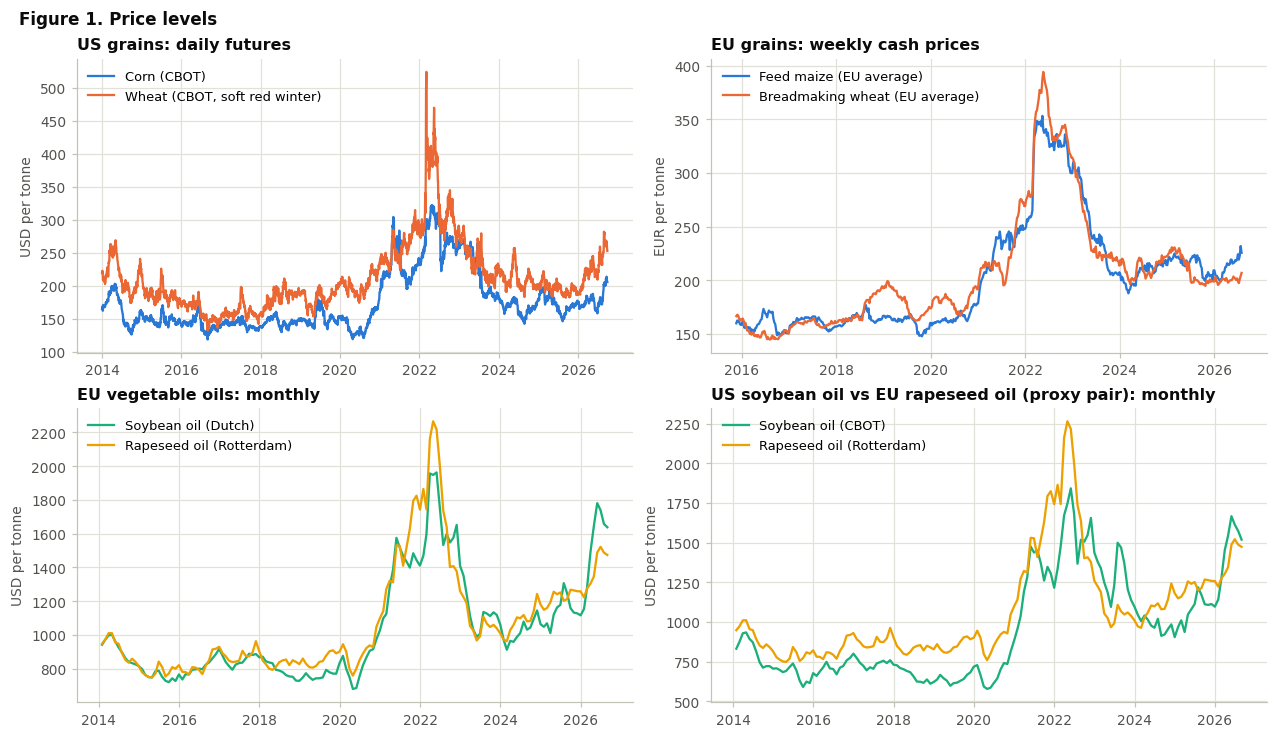

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.6), constrained_layout=True)
panels = [
    (axes[0, 0], us_clean, [("corn_us", "Corn (CBOT)"), ("wheat_us", "Wheat (CBOT, soft red winter)")],
     "US grains: daily futures", "USD per tonne"),
    (axes[0, 1], eu_clean, [("corn_eu", "Feed maize (EU average)"), ("wheat_eu", "Breadmaking wheat (EU average)")],
     "EU grains: weekly cash prices", "EUR per tonne"),
    (axes[1, 0], monthly, [("soyoil_eu", "Soybean oil (Dutch)"), ("rapeoil_eu", "Rapeseed oil (Rotterdam)")],
     "EU vegetable oils: monthly", "USD per tonne"),
    (axes[1, 1], monthly, [("soyoil_us", "Soybean oil (CBOT)"), ("rapeoil_eu", "Rapeseed oil (Rotterdam)")],
     "US soybean oil vs EU rapeseed oil (proxy pair): monthly", "USD per tonne"),
]
for ax, df, series, title, unit in panels:
    for col, label in series:
        ax.plot(df.index, df[col], color=COLORS[commodity(col)], label=label)
    ax.set_title(title, loc="left")
    ax.set_ylabel(unit)
    ax.legend(loc="upper left")
fig_title(fig, "Figure 1. Price levels")
plt.show()

### 4.2 Return distributions
Log returns at each series' own frequency and on a common monthly grid. Jarque–Bera tests normality; `autocorr_lag1` is first-order autocorrelation.

In [14]:
def return_stats(prices, periods_per_year):
    r = np.log(prices).diff().dropna(how="all")
    return pd.DataFrame({
        "obs": r.count(),
        "mean_%_pa": 100 * r.mean() * periods_per_year,
        "vol_%_pa": 100 * r.std() * np.sqrt(periods_per_year),
        "skew": r.skew(),
        "excess_kurtosis": r.kurt(),
        "JB_pvalue": r.apply(lambda x: stats.jarque_bera(x.dropna()).pvalue),
        "autocorr_lag1": r.apply(lambda x: x.autocorr(1)),
    }).rename(index=LABELS)


print("Daily log returns: US futures")
display(return_stats(us_clean, 252))
print("Weekly log returns: common US-EU window (local currency)")
display(return_stats(common_weekly, 52))
print("Monthly log returns: common window")
display(return_stats(monthly[MONTHLY_SERIES].dropna(), 12))

Daily log returns: US futures


,obs,mean_%_pa,vol_%_pa,skew,excess_kurtosis,JB_pvalue,autocorr_lag1
US corn,3199,1.603,25.100,-1.194,15.491,0.000,-0.001
US wheat,3201,1.111,30.769,0.520,4.903,0.000,0.037
US soybean oil,3201,4.433,25.613,-0.165,2.166,0.000,0.068


Weekly log returns: common US-EU window (local currency)


,obs,mean_%_pa,vol_%_pa,skew,excess_kurtosis,JB_pvalue,autocorr_lag1
US corn,558,1.802,25.662,-0.908,6.302,0.000,-0.045
US wheat,558,2.506,31.752,1.828,23.409,0.000,-0.104
EU maize,558,3.215,12.478,0.974,9.011,0.000,0.012
EU wheat,558,2.022,10.949,0.778,4.788,0.000,0.217


Monthly log returns: common window


,obs,mean_%_pa,vol_%_pa,skew,excess_kurtosis,JB_pvalue,autocorr_lag1
US corn,128,1.808,20.196,-0.230,0.816,0.135,0.293
US wheat,128,2.513,22.779,0.637,5.043,0.000,0.008
US soybean oil,128,8.817,22.266,-0.045,0.568,0.503,0.256
EU maize,128,3.122,12.601,1.738,11.723,0.000,0.347
EU wheat,128,1.762,12.819,1.062,5.602,0.000,0.495
EU soybean oil,128,7.729,19.938,0.233,1.026,0.054,0.351
EU rapeseed oil,128,5.818,18.872,0.231,1.973,0.000,0.211


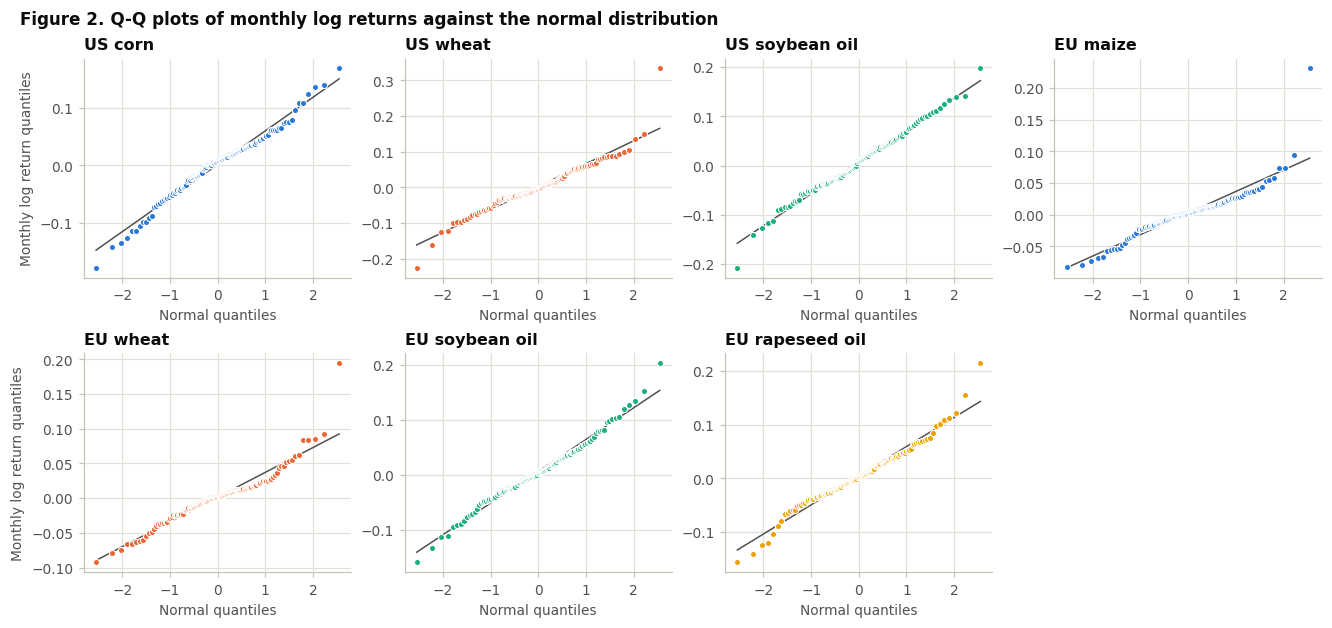

In [15]:
r_monthly = np.log(monthly[MONTHLY_SERIES]).diff().dropna()
fig, axes = plt.subplots(2, 4, figsize=(12, 5.6), constrained_layout=True)
for ax, col in zip(axes.flat, MONTHLY_SERIES):
    (theoretical, ordered), (slope, intercept, _) = stats.probplot(r_monthly[col], dist="norm")
    ax.plot(theoretical, slope * theoretical + intercept, color=INK2, lw=1)
    ax.plot(theoretical, ordered, "o", ms=4, color=COLORS[commodity(col)], mec="white", mew=0.7)
    ax.set_title(LABELS[col], loc="left")
    ax.set_xlabel("Normal quantiles")
axes[0, 0].set_ylabel("Monthly log return quantiles")
axes[1, 0].set_ylabel("Monthly log return quantiles")
axes.flat[-1].axis("off")
fig_title(fig, "Figure 2. Q-Q plots of monthly log returns against the normal distribution")
plt.show()

### 4.3 Correlation and volatility

In [16]:
print("Correlation of monthly log returns")
display(r_monthly.rename(columns=LABELS).corr().round(2))

# Cross-region integration: weekly returns in USD (EU prices converted with EUR/USD)
usd = weekly[GRAINS + ["eurusd"]].dropna().copy()
usd[["corn_eu", "wheat_eu"]] = usd[["corn_eu", "wheat_eu"]].mul(usd["eurusd"], axis=0)
r_usd = np.log(usd[GRAINS]).diff().dropna()
cross = pd.DataFrame({
    name: {"same_week": r_usd[us].corr(r_usd[eu]),
           "US_leads_by_1_week": r_usd[us].shift(1).corr(r_usd[eu]),
           "EU_leads_by_1_week": r_usd[eu].shift(1).corr(r_usd[us])}
    for name, us, eu in [("Corn: US vs EU", "corn_us", "corn_eu"), ("Wheat: US vs EU", "wheat_us", "wheat_eu")]
}).T
print("Cross-region correlation of weekly USD returns")
display(cross)

Correlation of monthly log returns


,US corn,US wheat,US soybean oil,EU maize,EU wheat,EU soybean oil,EU rapeseed oil
US corn,1.000,0.640,0.320,0.350,0.460,0.300,0.300
US wheat,0.640,1.000,0.360,0.480,0.580,0.350,0.380
US soybean oil,0.320,0.360,1.000,0.350,0.210,0.830,0.560
EU maize,0.350,0.480,0.350,1.000,0.610,0.440,0.410
EU wheat,0.460,0.580,0.210,0.610,1.000,0.270,0.480
EU soybean oil,0.300,0.350,0.830,0.440,0.270,1.000,0.640
EU rapeseed oil,0.300,0.380,0.560,0.410,0.480,0.640,1.000


Cross-region correlation of weekly USD returns


,same_week,US_leads_by_1_week,EU_leads_by_1_week
Corn: US vs EU,0.158,0.018,0.021
Wheat: US vs EU,0.153,0.274,-0.039


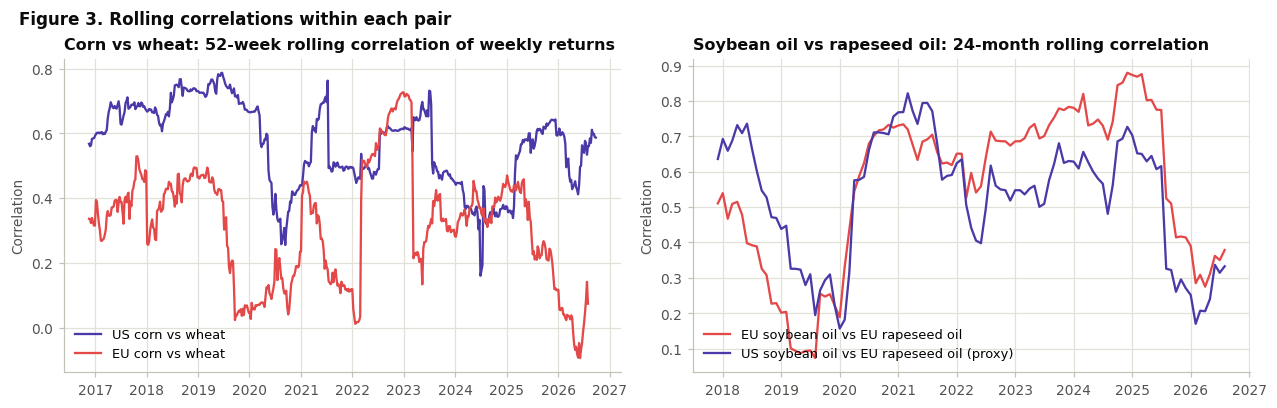

In [17]:
r_weekly = np.log(weekly[GRAINS]).diff()
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), constrained_layout=True)

ax = axes[0]
for region, (c, w) in {"US": ("corn_us", "wheat_us"), "EU": ("corn_eu", "wheat_eu")}.items():
    ax.plot(r_weekly[c].rolling(52).corr(r_weekly[w]), color=REGION[region], label=f"{region} corn vs wheat")
ax.set_title("Corn vs wheat: 52-week rolling correlation of weekly returns", loc="left")
ax.set_ylabel("Correlation")
ax.legend(loc="lower left")

ax = axes[1]
for label, (a, b, color) in {"EU soybean oil vs EU rapeseed oil": ("soyoil_eu", "rapeoil_eu", REGION["EU"]),
                             "US soybean oil vs EU rapeseed oil (proxy)": ("soyoil_us", "rapeoil_eu", REGION["US"])}.items():
    ax.plot(r_monthly[a].rolling(24).corr(r_monthly[b]), color=color, label=label)
ax.set_title("Soybean oil vs rapeseed oil: 24-month rolling correlation", loc="left")
ax.set_ylabel("Correlation")
ax.legend(loc="lower left")
fig_title(fig, "Figure 3. Rolling correlations within each pair")
plt.show()

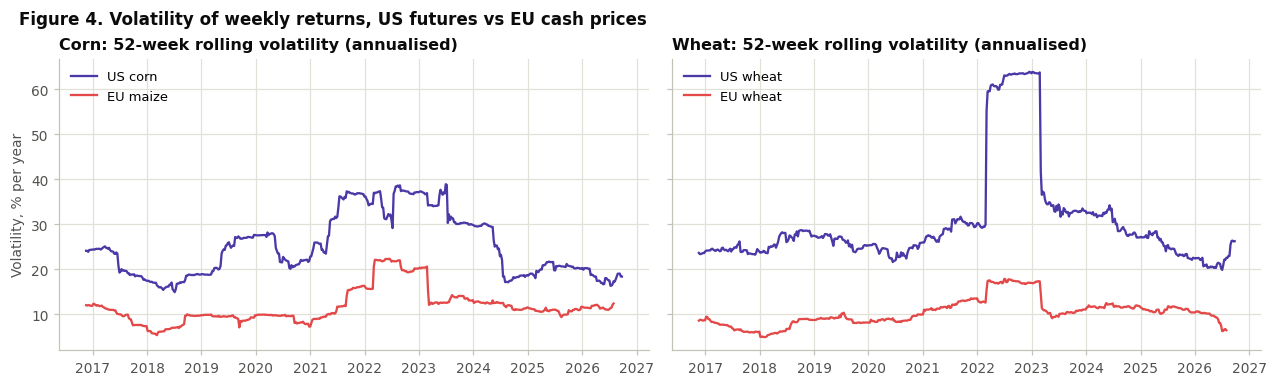

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4), constrained_layout=True, sharey=True)
for ax, crop in zip(axes, ["corn", "wheat"]):
    for region in ["US", "EU"]:
        col = f"{crop}_{region.lower()}"
        ax.plot(100 * r_weekly[col].rolling(52).std() * np.sqrt(52), color=REGION[region], label=LABELS[col])
    ax.set_title(f"{crop.capitalize()}: 52-week rolling volatility (annualised)", loc="left")
    ax.legend(loc="upper left")
axes[0].set_ylabel("Volatility, % per year")
fig_title(fig, "Figure 4. Volatility of weekly returns, US futures vs EU cash prices")
plt.show()

## 5. Seasonality and ARIMA
Three views of seasonality on monthly log prices:
- **STL:** seasonal strength and average seasonal profile.
- **FFT periodogram of returns:** dominant cycle length.
- **Seasonal dummies:** F-test that all month effects are zero.

ARMA models are then fitted to monthly log returns, equivalent to `ARIMA(p,1,q)` on log prices.

In [19]:
def month_dummy_pvalue(r):
    """F-test p-value that all calendar-month effects in r are zero."""
    r = r.dropna()
    dummies = pd.get_dummies(r.index.month, prefix="m", drop_first=True).astype(float).set_index(r.index)
    return sm.OLS(r, sm.add_constant(dummies)).fit().f_pvalue


def seasonality(prices):
    rows, profiles, spectra = {}, {}, {}
    for col in prices:
        x = np.log(prices[col].dropna())
        stl = STL(x, period=12, robust=True).fit()
        strength = max(0.0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
        profile = 100 * stl.seasonal.groupby(stl.seasonal.index.month).mean()
        r = x.diff().dropna()
        freq, power = signal.periodogram(r - r.mean(), fs=12)      # frequency in cycles per year
        k = np.argmax(power[1:]) + 1
        rows[LABELS[col]] = {"seasonal_strength": strength,
                             "seasonal_amplitude_%": profile.max() - profile.min(),
                             "seasonal_high": calendar.month_abbr[profile.idxmax()],
                             "seasonal_low": calendar.month_abbr[profile.idxmin()],
                             "dominant_cycle_months": 12 / freq[k],
                             "month_dummies_F_pvalue": month_dummy_pvalue(r)}
        profiles[col], spectra[col] = profile, pd.Series(power, index=freq)
    return pd.DataFrame(rows).T, pd.DataFrame(profiles), spectra


season_table, season_profiles, spectra = seasonality(monthly[MONTHLY_SERIES])
season_table

,seasonal_strength,seasonal_amplitude_%,seasonal_high,seasonal_low,dominant_cycle_months,month_dummies_F_pvalue
US corn,0.078,19.773,Apr,Sep,11.615,0.000
US wheat,0.040,11.408,May,Sep,4.871,0.635
US soybean oil,0.000,16.738,May,Sep,50.333,0.915
EU maize,0.154,8.379,Jun,Oct,64.000,0.005
EU wheat,0.051,7.956,Feb,Aug,42.667,0.013
EU soybean oil,0.000,17.794,May,Mar,50.333,0.943
EU rapeseed oil,0.100,5.243,Jun,Feb,50.333,0.482


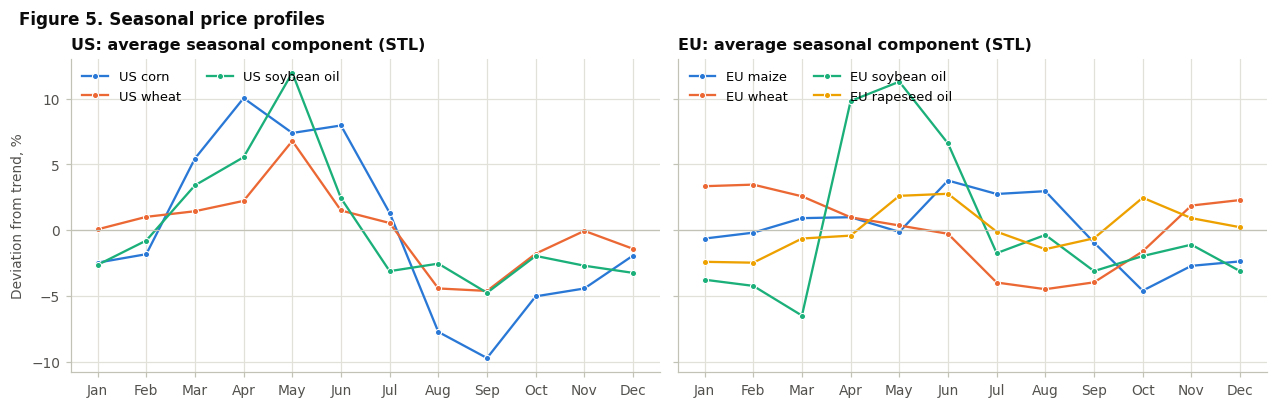

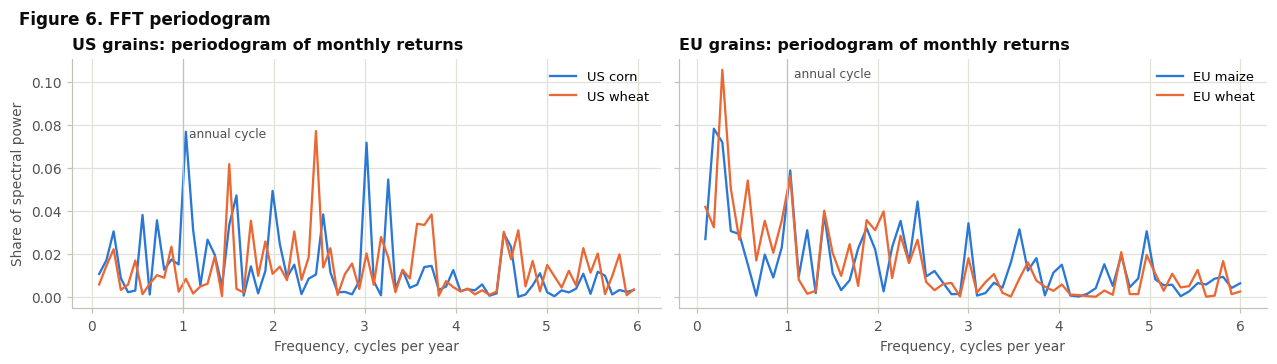

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), constrained_layout=True, sharey=True)
for ax, (region, cols) in zip(axes, {"US": ["corn_us", "wheat_us", "soyoil_us"],
                                     "EU": ["corn_eu", "wheat_eu", "soyoil_eu", "rapeoil_eu"]}.items()):
    for col in cols:
        ax.plot(season_profiles.index, season_profiles[col], color=COLORS[commodity(col)], marker="o", ms=4,
                mec="white", mew=0.7, label=LABELS[col])
    ax.axhline(0, color=AXIS, lw=0.8)
    ax.set_xticks(range(1, 13), [calendar.month_abbr[m] for m in range(1, 13)])
    ax.set_title(f"{region}: average seasonal component (STL)", loc="left")
    ax.legend(loc="upper left", ncol=2)
axes[0].set_ylabel("Deviation from trend, %")
fig_title(fig, "Figure 5. Seasonal price profiles")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.2), constrained_layout=True, sharey=True)
for ax, (region, cols) in zip(axes, {"US": ["corn_us", "wheat_us"], "EU": ["corn_eu", "wheat_eu"]}.items()):
    for col in cols:
        s = spectra[col].iloc[1:]
        ax.plot(s.index, s / s.sum(), color=COLORS[commodity(col)], label=LABELS[col])
    ax.axvline(1, color=AXIS, lw=0.8)
    ax.annotate("annual cycle", (1, ax.get_ylim()[1] * 0.92), xytext=(4, 0), textcoords="offset points", color=INK2, fontsize=8)
    ax.set_title(f"{region} grains: periodogram of monthly returns", loc="left")
    ax.set_xlabel("Frequency, cycles per year")
    ax.legend(loc="upper right")
axes[0].set_ylabel("Share of spectral power")
fig_title(fig, "Figure 6. FFT periodogram")
plt.show()

In [21]:
def best_arma(r, max_p=2, max_q=2):
    """Select ARMA(p,q) with a constant by AIC; Ljung-Box test on the residuals at lag 12."""
    best, order = None, None
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                res = ARIMA(r.values, order=(p, 0, q), trend="c").fit()
            except Exception:
                continue
            if best is None or res.aic < best.aic:
                best, order = res, (p, q)
    coefs = ", ".join(f"{n}={v:.2f}" for n, v in zip(best.param_names, best.params) if n.startswith(("ar", "ma")))
    return {"selected": f"ARMA{order}", "AIC": best.aic, "coefficients": coefs or "none (white noise)",
            "LjungBox_p_lag12": acorr_ljungbox(best.resid, lags=[12], return_df=True)["lb_pvalue"].iloc[0]}


r_pct = 100 * np.log(monthly[MONTHLY_SERIES]).diff()
arima_table = pd.DataFrame({LABELS[c]: best_arma(r_pct[c].dropna()) for c in MONTHLY_SERIES}).T
arima_table

,selected,AIC,coefficients,LjungBox_p_lag12
US corn,"ARMA(0, 1)",951.171,ma.L1=0.38,0.725
US wheat,"ARMA(2, 0)","1,002.657","ar.L1=0.04, ar.L2=-0.18",0.578
US soybean oil,"ARMA(1, 0)",973.002,ar.L1=0.28,0.198
EU maize,"ARMA(1, 0)",682.493,ar.L1=0.35,0.469
EU wheat,"ARMA(0, 2)",666.924,"ma.L1=0.50, ma.L2=0.31",0.574
EU soybean oil,"ARMA(2, 2)",922.527,"ar.L1=0.61, ar.L2=-0.57, ma.L1=-0.29, ma.L2=0.63",0.497
EU rapeseed oil,"ARMA(1, 0)",927.152,ar.L1=0.22,0.831


## 6. Price relationships: stationarity, correlation, cointegration
### 6.1 Unit-root tests
ADF (null: unit root) and KPSS (null: stationary) on log prices, plus ADF on log returns. A series is $I(1)$ when the level has a unit root and the return is stationary. KPSS p-values are reported within $[0.01,\ 0.10]$.

In [22]:
def unit_root_table(prices):
    rows = {}
    for col in prices:
        x = np.log(prices[col].dropna())
        adf_level = adfuller(x, regression="ct", autolag="AIC")[1]
        kpss_level = kpss(x, regression="c", nlags="auto")[1]
        adf_return = adfuller(x.diff().dropna(), regression="c", autolag="AIC")[1]
        rows[LABELS[col]] = {"obs": len(x), "ADF_p_level": adf_level, "KPSS_p_level": kpss_level,
                             "ADF_p_return": adf_return,
                             "order": "I(1)" if (adf_level > 0.05 and adf_return < 0.05) else "check"}
    return pd.DataFrame(rows).T


print("Weekly grains (each series on its own sample)")
display(unit_root_table(weekly[GRAINS]))
print("Monthly vegetable oils")
display(unit_root_table(monthly[["soyoil_us", "soyoil_eu", "rapeoil_eu"]]))

Weekly grains (each series on its own sample)


,obs,ADF_p_level,KPSS_p_level,ADF_p_return,order
US corn,567,0.549,0.010,0.000,I(1)
US wheat,567,0.313,0.010,0.000,I(1)
EU maize,559,0.818,0.010,0.000,I(1)
EU wheat,559,0.832,0.010,0.000,I(1)


Monthly vegetable oils


,obs,ADF_p_level,KPSS_p_level,ADF_p_return,order
US soybean oil,152,0.358,0.010,0.000,I(1)
EU soybean oil,152,0.129,0.010,0.000,I(1)
EU rapeseed oil,152,0.473,0.010,0.000,I(1)


### 6.2 Cointegration within each pair
**Engle–Granger** (residual-based, first commodity on the second) and **Johansen** trace tests, with lags by AIC and rank at 5%. The US corn–wheat pair is also run on the EU sample window for a like-for-like comparison.

In [23]:
def cointegration(df, y, x, max_lags):
    d = np.log(df[[y, x]].dropna())
    _, eg_p, _ = coint(d[y], d[x], trend="c", autolag="aic")
    beta = sm.OLS(d[y], sm.add_constant(d[x])).fit().params[x]
    lags = max(1, select_order(d, maxlags=max_lags, deterministic="ci").aic)
    jo = coint_johansen(d, det_order=0, k_ar_diff=lags)
    rank = int(np.cumprod(jo.lr1 > jo.cvt[:, 1]).sum())
    meaning = {0: "no cointegration", 1: "cointegrated (1 vector)",
               2: "full rank: both look stationary in this sample, check"}[rank]
    return {"sample": f"{d.index.min():%Y-%m} to {d.index.max():%Y-%m}", "obs": len(d), "beta": beta,
            "EG_pvalue": eg_p, "Johansen_lags": lags, "trace_r0": jo.lr1[0], "crit_5%_r0": jo.cvt[0, 1],
            "rank_5%": rank, "Johansen_reading": meaning}


COINT_SPECS = {   # name: (data, y, x, max lags)
    "US wheat~corn, weekly, full sample": (us_weekly, "wheat_us", "corn_us", 8),
    "US wheat~corn, weekly, EU window": (common_weekly, "wheat_us", "corn_us", 8),
    "EU wheat~maize, weekly": (common_weekly, "wheat_eu", "corn_eu", 8),
    "EU rapeseed~soybean oil, monthly, 2014+": (monthly, "rapeoil_eu", "soyoil_eu", 6),
    "EU rapeseed~soybean oil, monthly, 2000+": (wb_monthly.loc["2000":], "rapeoil_eu", "soyoil_eu", 6),
    "EU rapeseed~US soybean oil (proxy), monthly": (monthly, "rapeoil_eu", "soyoil_us", 6),
}
coint_table = pd.DataFrame({name: cointegration(*spec) for name, spec in COINT_SPECS.items()}).T
coint_table

,sample,obs,beta,EG_pvalue,Johansen_lags,trace_r0,crit_5%_r0,rank_5%,Johansen_reading
"US wheat~corn, weekly, full sample",2014-01 to 2026-09,665,0.831,0.003,1,25.384,15.494,1,cointegrated (1 vector)
"US wheat~corn, weekly, EU window",2015-11 to 2026-07,559,0.844,0.015,1,20.657,15.494,1,cointegrated (1 vector)
"EU wheat~maize, weekly",2015-11 to 2026-07,559,0.949,0.010,5,18.934,15.494,1,cointegrated (1 vector)
"EU rapeseed~soybean oil, monthly, 2014+",2014-01 to 2026-08,152,0.924,0.183,1,21.120,15.494,1,cointegrated (1 vector)
"EU rapeseed~soybean oil, monthly, 2000+",2002-02 to 2026-08,295,0.880,0.001,1,31.555,15.494,2,full rank: both look stationary in this sample...
"EU rapeseed~US soybean oil (proxy), monthly",2014-01 to 2026-08,152,0.728,0.045,1,13.446,15.494,0,no cointegration


Planned next: VECM and ARDL for region-specific adjustment speeds; threshold cointegration (TVECM) for asymmetric adjustment (Peri and Baldi, 2010); Granger causality and volatility spillovers between US and EU (Hernandez et al., 2014); structural-break tests around 2020–2022.

## 7. Weather and yields
Yields are regressed on growing-season weather using the nonlinear form of Schlenker and Roberts (2009) and Lobell et al. (2011):

$$\ln(\text{yield}_t) = \alpha + \beta\,t + \gamma_1 T_t + \gamma_2 T_t^2 + \delta_1 P_t + \delta_2 P_t^2 \;[+\ \theta\,T^{\text{winter}}_{t}] + \varepsilon_t$$

$T$ is mean growing-season temperature and $P$ season total precipitation, both standardised, so coefficients are log-yield changes per standard deviation. EU winter rapeseed adds the previous November–December temperature (Brown et al., 2019). Standard errors are robust (`HC3`).

| Crop, region | Weather points | Months |
|---|---|---|
| US corn | Iowa, Illinois | Jun–Aug |
| US soybeans | Iowa, Illinois | Jul–Aug |
| US wheat | Kansas, Illinois | Apr–Jun |
| EU maize | SW France, S Romania | Jun–Aug |
| EU wheat | Beauce (FR), N Germany, C Poland, S Romania | Apr–Jun |
| EU rapeseed | Champagne (FR), N Germany, C Poland | Mar–May, plus prior Nov–Dec |

In [24]:
CROP_WINDOWS = {   # (region, crop): (weather points, growing-season months, prior-year months or None)
    ("US", "corn"):     (["US_Iowa", "US_Illinois"], [6, 7, 8], None),
    ("US", "soybeans"): (["US_Iowa", "US_Illinois"], [7, 8], None),
    ("US", "wheat"):    (["US_Kansas", "US_Illinois"], [4, 5, 6], None),
    ("EU", "corn"):     (["EU_FR_SouthWest", "EU_RO_South"], [6, 7, 8], None),
    ("EU", "wheat"):    (["EU_FR_Beauce", "EU_DE_North", "EU_PL_Centre", "EU_RO_South"], [4, 5, 6], None),
    ("EU", "rapeseed"): (["EU_FR_Champagne", "EU_DE_North", "EU_PL_Centre"], [3, 4, 5], [11, 12]),
}


def season_features(region, crop):
    sites, months, prior = CROP_WINDOWS[(region, crop)]
    w = weather[weather["site"].isin(sites)].assign(year=lambda d: d.index.year, month=lambda d: d.index.month)
    s = w[w["month"].isin(months)]
    feats = pd.DataFrame({
        "tmean": s.groupby("year")["tmean"].mean(),                                # deg C, average of points and months
        "tmax": s.groupby(["year", "site"])["tmax"].max().groupby("year").mean(),  # deg C, hottest reading of season
        "prcp": s.groupby(["year", "site"])["prcp"].sum().groupby("year").mean(),  # mm, season total
    })
    if prior:   # months before harvest year (e.g. Nov-Dec before a winter rapeseed harvest)
        feats["tmean_prior_winter"] = w[w["month"].isin(prior)].groupby("year")["tmean"].mean().rename(lambda y: y + 1)
    return feats


def fit_weather_model(region, crop):
    data = pd.concat([np.log(yields[(region, crop)]).rename("ln_yield"), season_features(region, crop)], axis=1).dropna()
    raw = data.drop(columns=["ln_yield", "tmax"])
    z = (raw - raw.mean()) / raw.std()
    X = pd.DataFrame({"trend": data.index - data.index.min(), "T": z["tmean"], "T2": z["tmean"] ** 2,
                      "P": z["prcp"], "P2": z["prcp"] ** 2}, index=data.index)
    if "tmean_prior_winter" in z:
        X["T_winter"] = z["tmean_prior_winter"]
    res = sm.OLS(data["ln_yield"], sm.add_constant(X.astype(float))).fit(cov_type="HC3")
    return res, data


models, rows = {}, {}
for region, crop in CROP_WINDOWS:
    res, data = fit_weather_model(region, crop)
    models[(region, crop)] = (res, data)
    b, p, sd_t = res.params, res.pvalues, data["tmean"].std()
    row = {"years": f"{data.index.min()}-{data.index.max()}", "n": int(res.nobs), "R2": res.rsquared,
           "adj_R2": res.rsquared_adj, "T": b["T"], "p(T)": p["T"], "T2": b["T2"], "p(T2)": p["T2"],
           "P": b["P"], "p(P)": p["P"], "P2": b["P2"], "p(P2)": p["P2"],
           "yield_%_per_+1C_at_mean": 100 * b["T"] / sd_t,
           "Durbin_Watson": durbin_watson(res.resid),
           "Breusch_Pagan_p": het_breuschpagan(res.resid, res.model.exog)[1],
           "Jarque_Bera_p": jarque_bera(res.resid)[1]}
    if "T_winter" in b:
        row.update({"T_winter": b["T_winter"], "p(T_winter)": p["T_winter"]})
    rows[f"{region} {crop}"] = row
weather_table = pd.DataFrame(rows)
weather_table

,US corn,US soybeans,US wheat,EU corn,EU wheat,EU rapeseed
years,1981-2025,1981-2025,1981-2025,1999-2025,1999-2025,1999-2025
n,45,45,45,27,27,27
R2,0.923,0.919,0.779,0.761,0.592,0.411
adj_R2,0.913,0.909,0.751,0.704,0.495,0.234
T,-0.049,-0.033,-0.013,-0.081,-0.025,-0.014
p(T),0.001,0.005,0.343,0.003,0.080,0.523
T2,-0.005,-0.006,0.008,-0.005,-0.005,0.004
p(T2),0.378,0.400,0.321,0.776,0.575,0.765
P,0.025,0.012,-0.000,-0.003,-0.012,-0.028
p(P),0.046,0.274,0.974,0.914,0.606,0.191


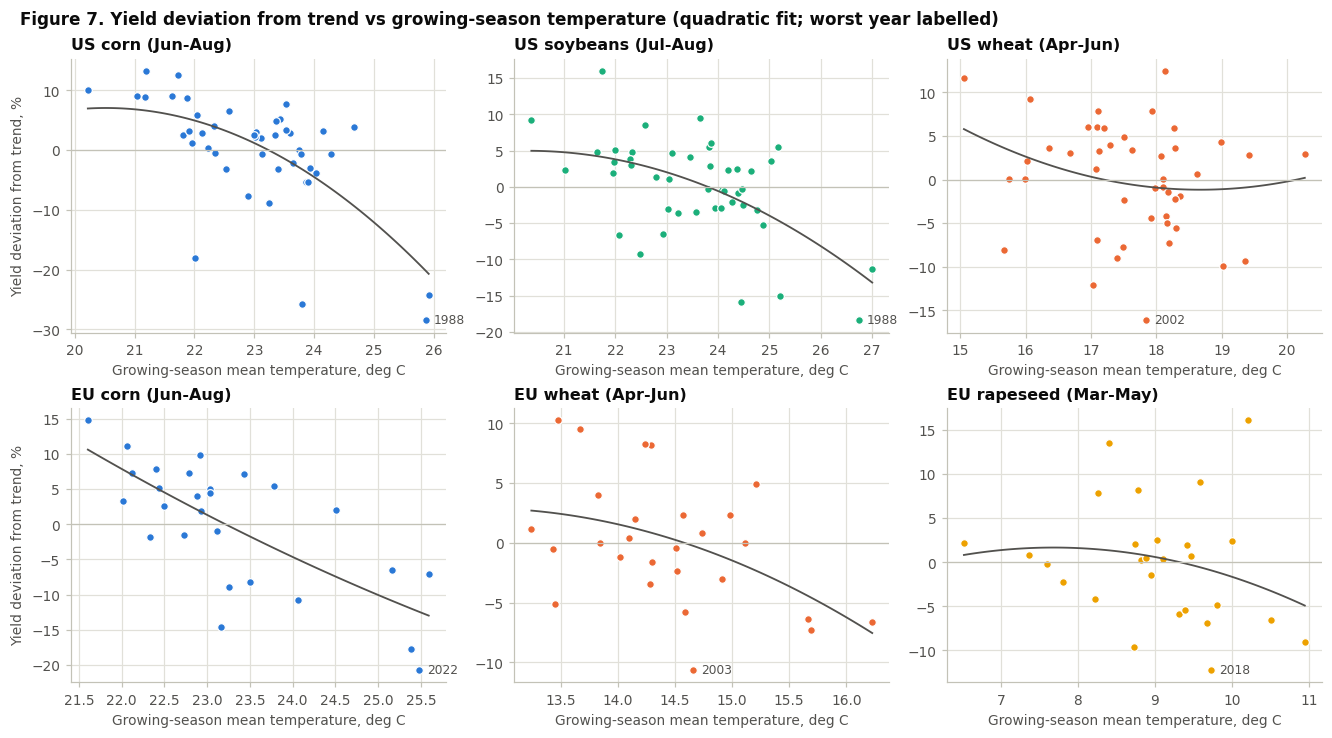

In [25]:
crop_color = {"corn": COLORS["corn"], "wheat": COLORS["wheat"], "soybeans": COLORS["soyoil"], "rapeseed": COLORS["rapeoil"]}
fig, axes = plt.subplots(2, 3, figsize=(12, 6.6), constrained_layout=True)
for ax, (region, crop) in zip(axes.flat, CROP_WINDOWS):
    res, data = models[(region, crop)]
    t = np.asarray(data.index - data.index.min(), dtype=float)
    anomaly = 100 * sm.OLS(data["ln_yield"], sm.add_constant(t)).fit().resid     # % deviation from linear trend
    x = data["tmean"]
    ax.plot(x, anomaly, "o", ms=5, color=crop_color[crop], mec="white", mew=0.8)
    grid = np.linspace(x.min(), x.max(), 100)
    ax.plot(grid, np.polyval(np.polyfit(x, anomaly, 2), grid), color=INK2, lw=1.2)
    worst = anomaly.idxmin()
    ax.annotate(str(worst), (x[worst], anomaly[worst]), xytext=(5, -2), textcoords="offset points", color=INK2, fontsize=8)
    ax.axhline(0, color=AXIS, lw=0.8)
    months = CROP_WINDOWS[(region, crop)][1]
    ax.set_title(f"{region} {crop} ({calendar.month_abbr[months[0]]}-{calendar.month_abbr[months[-1]]})", loc="left")
    ax.set_xlabel("Growing-season mean temperature, deg C")
for ax in axes[:, 0]:
    ax.set_ylabel("Yield deviation from trend, %")
fig_title(fig, "Figure 7. Yield deviation from trend vs growing-season temperature (quadratic fit; worst year labelled)")
plt.show()

## 8. Spreads and speed of mean reversion
Spreads are log price ratios, $s_t = \ln P^{A}_t - \ln P^{B}_t$, so units and currency drop out. Speed of mean reversion comes from a discretised Ornstein–Uhlenbeck (AR(1)) model:

$$\Delta s_t = a + b\, s_{t-1} + \varepsilon_t, \qquad \phi = 1 + b, \qquad \text{half-life} = \frac{\ln 2}{-\ln \phi}$$

The 95% half-life interval is mapped from the interval of $b$. A robustness column uses the Engle–Granger hedge-ratio spread, $\ln P^A - \beta \ln P^B$. `seasonal_F_p` tests calendar-month effects in spread changes (Simon, 1999).

In [26]:
def half_life(s):
    s = s.dropna()
    ds = s.diff().dropna()
    lag = s.shift(1).loc[ds.index]
    res = sm.OLS(ds, sm.add_constant(lag)).fit()
    b = res.params.iloc[1]
    b_low, b_high = res.conf_int().iloc[1]
    hl = lambda v: np.log(2) / -np.log(1 + v) if -1 < v < 0 else np.inf
    return {"phi": 1 + b, "half_life": hl(b), "hl_low": hl(b_low), "hl_high": hl(b_high)}


def spread_stats(a, b, unit, per_month):
    d = np.log(pd.concat([a, b], axis=1).dropna())
    s = d.iloc[:, 0] - d.iloc[:, 1]
    beta = sm.OLS(d.iloc[:, 0], sm.add_constant(d.iloc[:, 1])).fit().params.iloc[1]
    hr = half_life(s)
    return {"sample": f"{s.index.min():%Y-%m} to {s.index.max():%Y-%m}", "obs": len(s),
            "mean_price_ratio": np.exp(s.mean()), "sd_%": 100 * s.std(),
            "ADF_p": adfuller(s, regression="c", autolag="AIC")[1], "phi": hr["phi"],
            "half_life": hr["half_life"], "unit": unit,
            "half_life_months": hr["half_life"] / per_month,
            "hl_95%_months": f"{hr['hl_low'] / per_month:.1f} to {hr['hl_high'] / per_month:.1f}",
            "half_life_months_hedge_ratio": half_life(d.iloc[:, 0] - beta * d.iloc[:, 1])["half_life"] / per_month,
            "seasonal_F_p": month_dummy_pvalue(s.diff())}


WEEKS_PER_MONTH = 52 / 12
SPREADS = {   # name: (numerator, denominator, unit, periods per month)
    "US wheat/corn, weekly, full sample": (us_weekly["wheat_us"], us_weekly["corn_us"], "weeks", WEEKS_PER_MONTH),
    "US wheat/corn, weekly, EU window": (common_weekly["wheat_us"], common_weekly["corn_us"], "weeks", WEEKS_PER_MONTH),
    "EU wheat/maize, weekly": (common_weekly["wheat_eu"], common_weekly["corn_eu"], "weeks", WEEKS_PER_MONTH),
    "US wheat/corn, monthly": (monthly["wheat_us"], monthly["corn_us"], "months", 1),
    "EU wheat/maize, monthly": (monthly["wheat_eu"], monthly["corn_eu"], "months", 1),
    "EU rapeseed/soybean oil, monthly": (monthly["rapeoil_eu"], monthly["soyoil_eu"], "months", 1),
    "EU rapeseed/US soybean oil (proxy), monthly": (monthly["rapeoil_eu"], monthly["soyoil_us"], "months", 1),
}
spread_table = pd.DataFrame({name: spread_stats(*spec) for name, spec in SPREADS.items()}).T
spread_table

,sample,obs,mean_price_ratio,sd_%,ADF_p,phi,half_life,unit,half_life_months,hl_95%_months,half_life_months_hedge_ratio,seasonal_F_p
"US wheat/corn, weekly, full sample",2014-01 to 2026-09,665,1.210,10.193,0.001,0.930,9.558,weeks,2.206,1.6 to 3.7,2.030,0.552
"US wheat/corn, weekly, EU window",2015-11 to 2026-07,559,1.194,10.352,0.005,0.931,9.764,weeks,2.253,1.5 to 4.1,2.113,0.590
"EU wheat/maize, weekly",2015-11 to 2026-07,559,1.016,7.316,0.002,0.971,23.563,weeks,5.438,3.2 to 18.7,5.628,0.000
"US wheat/corn, monthly",2014-01 to 2026-08,152,1.209,9.808,0.004,0.863,4.702,months,4.702,2.8 to 12.5,4.361,0.142
"EU wheat/maize, monthly",2015-11 to 2026-07,129,1.016,7.186,0.130,0.909,7.253,months,7.253,3.7 to 53.7,7.383,0.000
"EU rapeseed/soybean oil, monthly",2014-01 to 2026-08,152,1.038,7.951,0.099,0.846,4.157,months,4.157,2.5 to 10.4,4.102,0.672
"EU rapeseed/US soybean oil (proxy), monthly",2014-01 to 2026-08,152,1.141,14.394,0.128,0.936,10.560,months,10.560,5.3 to 143.6,8.641,0.447


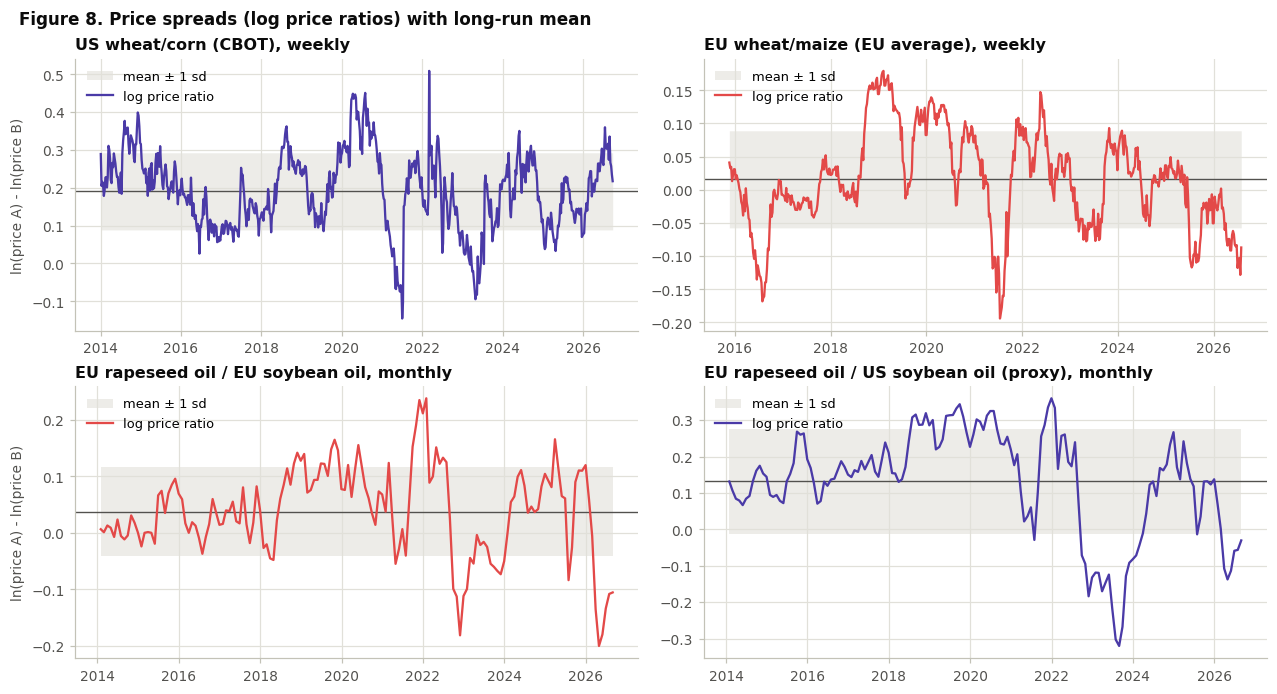

In [27]:
spread_panels = [
    ("US wheat/corn (CBOT), weekly", us_weekly["wheat_us"], us_weekly["corn_us"], REGION["US"]),
    ("EU wheat/maize (EU average), weekly", eu_clean["wheat_eu"], eu_clean["corn_eu"], REGION["EU"]),
    ("EU rapeseed oil / EU soybean oil, monthly", monthly["rapeoil_eu"], monthly["soyoil_eu"], REGION["EU"]),
    ("EU rapeseed oil / US soybean oil (proxy), monthly", monthly["rapeoil_eu"], monthly["soyoil_us"], REGION["US"]),
]
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.2), constrained_layout=True)
for ax, (title, a, b, color) in zip(axes.flat, spread_panels):
    s = (np.log(a) - np.log(b)).dropna()
    ax.fill_between(s.index, s.mean() - s.std(), s.mean() + s.std(), color=GRID, alpha=0.6, lw=0, label="mean ± 1 sd")
    ax.axhline(s.mean(), color=INK2, lw=0.9)
    ax.plot(s.index, s, color=color, label="log price ratio")
    ax.set_title(title, loc="left")
    ax.legend(loc="upper left")
for ax in axes[:, 0]:
    ax.set_ylabel("ln(price A) - ln(price B)")
fig_title(fig, "Figure 8. Price spreads (log price ratios) with long-run mean")
plt.show()

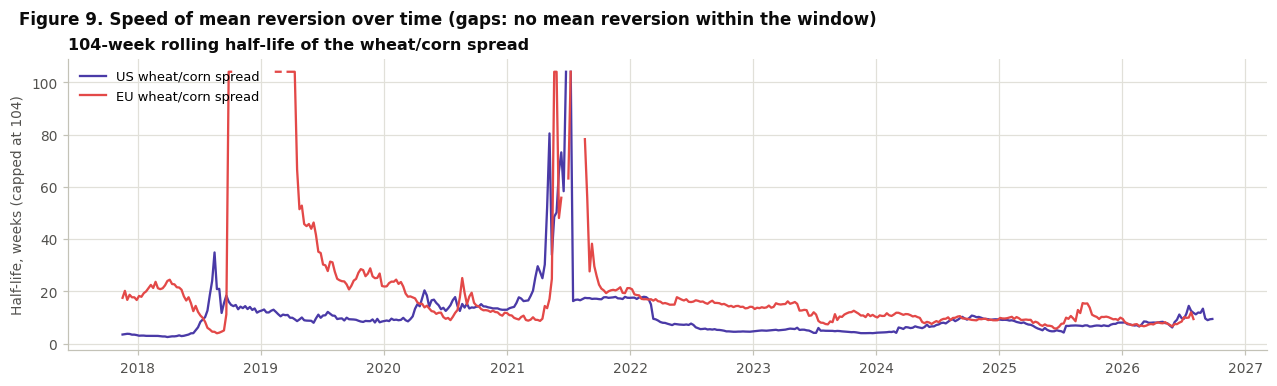

In [28]:
def rolling_half_life(s, window):
    """Half-life (periods) of an AR(1) fitted in a rolling window; NaN where the window shows no mean reversion."""
    s = s.dropna()
    lag, ds = s.shift(1), s.diff()
    b = ds.rolling(window).cov(lag) / lag.rolling(window).var()
    return (np.log(2) / -np.log(1 + b)).where((b < 0) & (b > -1))


WINDOW = 104   # two years of weekly data
fig, ax = plt.subplots(figsize=(11.5, 3.4), constrained_layout=True)
for region, (a, b) in {"US": ("wheat_us", "corn_us"), "EU": ("wheat_eu", "corn_eu")}.items():
    hl = rolling_half_life(np.log(weekly[a]) - np.log(weekly[b]), WINDOW)
    ax.plot(hl.clip(upper=WINDOW), color=REGION[region], label=f"{region} wheat/corn spread")
ax.set_ylabel("Half-life, weeks (capped at 104)")
ax.set_title("104-week rolling half-life of the wheat/corn spread", loc="left")
ax.legend(loc="upper left")
fig_title(fig, "Figure 9. Speed of mean reversion over time (gaps: no mean reversion within the window)")
plt.show()

## 9. Initial findings (preliminary)

In [29]:
def fmt_p(p):
    return f"{p:.3f}" if p >= 0.001 else "<0.001"


headline = pd.DataFrame({
    "US corn-wheat": {
        "Return correlation": r_weekly["corn_us"].corr(r_weekly["wheat_us"]),
        "Cointegrated at 5% (Johansen rank)": coint_table.loc["US wheat~corn, weekly, EU window", "rank_5%"],
        "Engle-Granger p": fmt_p(coint_table.loc["US wheat~corn, weekly, EU window", "EG_pvalue"]),
        "Spread half-life, months": spread_table.loc["US wheat/corn, weekly, EU window", "half_life_months"],
        "Spread ADF p": fmt_p(spread_table.loc["US wheat/corn, weekly, EU window", "ADF_p"]),
    },
    "EU corn-wheat": {
        "Return correlation": r_weekly["corn_eu"].corr(r_weekly["wheat_eu"]),
        "Cointegrated at 5% (Johansen rank)": coint_table.loc["EU wheat~maize, weekly", "rank_5%"],
        "Engle-Granger p": fmt_p(coint_table.loc["EU wheat~maize, weekly", "EG_pvalue"]),
        "Spread half-life, months": spread_table.loc["EU wheat/maize, weekly", "half_life_months"],
        "Spread ADF p": fmt_p(spread_table.loc["EU wheat/maize, weekly", "ADF_p"]),
    },
    "EU soybean-rapeseed oil": {
        "Return correlation": r_monthly["soyoil_eu"].corr(r_monthly["rapeoil_eu"]),
        "Cointegrated at 5% (Johansen rank)": coint_table.loc["EU rapeseed~soybean oil, monthly, 2014+", "rank_5%"],
        "Engle-Granger p": fmt_p(coint_table.loc["EU rapeseed~soybean oil, monthly, 2014+", "EG_pvalue"]),
        "Spread half-life, months": spread_table.loc["EU rapeseed/soybean oil, monthly", "half_life_months"],
        "Spread ADF p": fmt_p(spread_table.loc["EU rapeseed/soybean oil, monthly", "ADF_p"]),
    },
    "US soybean oil - EU rapeseed oil (proxy)": {
        "Return correlation": r_monthly["soyoil_us"].corr(r_monthly["rapeoil_eu"]),
        "Cointegrated at 5% (Johansen rank)": coint_table.loc["EU rapeseed~US soybean oil (proxy), monthly", "rank_5%"],
        "Engle-Granger p": fmt_p(coint_table.loc["EU rapeseed~US soybean oil (proxy), monthly", "EG_pvalue"]),
        "Spread half-life, months": spread_table.loc["EU rapeseed/US soybean oil (proxy), monthly", "half_life_months"],
        "Spread ADF p": fmt_p(spread_table.loc["EU rapeseed/US soybean oil (proxy), monthly", "ADF_p"]),
    },
})
print("Headline results (weekly grains on the common US-EU window; monthly vegetable oils)")
display(headline)
print("Weather and yield models: fit and marginal effect of +1 deg C at the sample mean")
display(weather_table.loc[["n", "R2", "adj_R2", "yield_%_per_+1C_at_mean", "p(T)", "p(T2)", "p(P)"]])

Headline results (weekly grains on the common US-EU window; monthly vegetable oils)


,US corn-wheat,EU corn-wheat,EU soybean-rapeseed oil,US soybean oil - EU rapeseed oil (proxy)
Return correlation,0.549,0.385,0.637,0.565
Cointegrated at 5% (Johansen rank),1,1,1,0
Engle-Granger p,0.015,0.010,0.183,0.045
"Spread half-life, months",2.253,5.438,4.157,10.560
Spread ADF p,0.005,0.002,0.099,0.128


Weather and yield models: fit and marginal effect of +1 deg C at the sample mean


,US corn,US soybeans,US wheat,EU corn,EU wheat,EU rapeseed
n,45,45,45,27,27,27
R2,0.923,0.919,0.779,0.761,0.592,0.411
adj_R2,0.913,0.909,0.751,0.704,0.495,0.234
yield_%_per_+1C_at_mean,-4.114,-2.413,-1.199,-7.340,-3.431,-1.433
p(T),0.001,0.005,0.343,0.003,0.080,0.523
p(T2),0.378,0.400,0.321,0.776,0.575,0.765
p(P),0.046,0.274,0.974,0.914,0.606,0.191


**Summary of initial results** (data as of 28 September 2026; tables above update on re-run)

1. **Data properties.** All seven price series are $I(1)$ in logs (ADF and KPSS agree) and returns are fat-tailed and non-normal (Jarque–Bera $p < 0.05$ for most; daily US corn excess kurtosis 15). US futures are two to three times as volatile as EU cash prices (26–32% vs 11–12% a year, weekly). Part of this is the instrument: EU series are weekly averages of cash quotes, so a futures-to-futures comparison is planned.

2. **Price relationships.** Corn and wheat are cointegrated in **both** regions over the same 2015–2026 window (Johansen rank 1; Engle–Granger $p = 0.015$ US, $p = 0.010$ EU), so the long-run grain link holds on both sides of the Atlantic. Short-run co-movement is stronger in the US (weekly return correlation 0.55 vs 0.39). Vegetable oils are mixed: the EU pair is cointegrated by Johansen but not Engle–Granger over 2014–2026 ($p = 0.18$), though Engle–Granger does reject on the longer 2002–2026 sample ($p = 0.001$); the US proxy pair is borderline (Engle–Granger $p = 0.045$, Johansen rank 0).

3. **Links between regions.** Same-week US–EU return correlations in USD are low (about 0.15), but US wheat leads EU wheat by one week (0.27), consistent with Chicago's leading role (Hernandez et al., 2014), though weekly averaging of EU prices also contributes.

4. **Seasonality.** Month effects are significant for US corn ($p < 0.001$; peak in spring, trough at the September harvest), EU maize ($p = 0.005$) and EU wheat ($p = 0.013$), but not US wheat or the oils. The periodogram confirms an annual cycle for US corn (11.6 months). Low-order ARMA leaves no residual autocorrelation (Ljung–Box $p > 0.19$).

5. **Weather and yields.** Warmer seasons lower yields in both regions: at the sample mean, $+1^{o}C$ goes with about $-4.1\%$ for US corn ($p = 0.001$), $-2.4\%$ US soybeans ($p = 0.005$), $-7.3\%$ EU maize ($p = 0.003$) and $-3.4\%$ EU wheat ($p = 0.08$). US corn shows an inverted-U rainfall response ($P > 0$, $P^2 < 0$, $p \approx 0.05$), as in Schlenker and Roberts (2009). US wheat and EU rapeseed show no significant effect in this first pass, and early-winter temperature is not significant for EU rapeseed; the EU sample is short (27 years) and the weather points coarse. The worst year in each model matches a known drought or heatwave (US 1988; EU 2003, 2018, 2022).

6. **Spreads and mean reversion.** Wheat/corn spreads are stationary in both regions (weekly ADF $p \le 0.005$), but the **EU spread reverts more slowly**: half-life about 5.4 months (95% CI 3.2–18.7) against 2.3 months (1.5–4.1) in the US over the same window. The EU spread is also seasonal ($p < 0.001$) while the US spread is not. Oil spreads revert more slowly and less reliably (EU about 4.2 months, ADF $p = 0.10$; proxy pair about 10.6 months, not significant). Half-lives are longer on monthly averages, so frequency effects need further testing.

## References
- Brown, J. K. M., Beeby, R., and Penfield, S. (2019). Yield instability of winter oilseed rape modulated by early winter temperature. *Scientific Reports*, 9, 6953.
- Hernandez, M. A., Ibarra, R., and Trupkin, D. R. (2014). How far do shocks move across borders? *European Review of Agricultural Economics*, 41(2), 301–325.
- Lobell, D. B., Schlenker, W., and Costa-Roberts, J. (2011). Climate trends and global crop production since 1980. *Science*, 333(6042), 616–620.
- Peri, M., and Baldi, L. (2010). Vegetable oil market and biofuel policy: An asymmetric cointegration approach. *Energy Economics*, 32(3), 687–693.
- Schlenker, W., and Roberts, M. J. (2009). Nonlinear temperature effects indicate severe damages to U.S. crop yields under climate change. *PNAS*, 106(37), 15594–15598.
- Simon, D. P. (1999). The soybean crush spread: Empirical evidence and trading strategies. *Journal of Futures Markets*, 19(3), 271–289.

Data: Yahoo Finance; European Commission Agri-food Data Portal; World Bank Commodity Price Data (Pink Sheet); NASA POWER; USDA FAS PSD Online.